*torchvision* - base domain library for computer vision

*torchvision.datasets* - cv datasets 

*torchvision.transforms* - functions for manipulating vision data

*torch.utils.data.Dataset* - Base dataset class for pytroch models

*torch.utils.data.Dataloader* - Creats a python iterable over a dataset

In [45]:

#Importing required libraries
import torch
from torch import nn
import torchvision
from torchvision import datasets
from torchvision import transforms

from torchvision.transforms import ToTensor 

import pandas as pd

import matplotlib.pyplot as plt
#checking versions
print(torch.__version__)
print(torchvision.__version__)

2.5.1
0.20.1


## 1.Getting a dataset    

used dataset : FashoinMNIST.

where to find datasets? 

https://www.image-net.org/

https://docs.pytorch.org/vision/stable/datasets.html

used dataset reference link  : https://github.com/zalandoresearch/fashion-mnist



In [46]:
#setting up training data
train_data = datasets.FashionMNIST(
    root= "data", #Where to download data to ?
    train= True, #Do we want the training dataset
    download = True, # Do we want to download the dataset
    transform= ToTensor(), #Transform the images into tensors
    target_transform= None # Do we want to transform the labels 


)

test_data = datasets.FashionMNIST(
    root = "data" ,
    train = False , #testing dataset
    download=True,
    transform= ToTensor(),
    target_transform = None

)

In [47]:
len(train_data) , len(test_data)
#print(f"Test data dim {test_data.shape()}, Train data dim {train_data.shape()}"


(60000, 10000)

In [48]:
image , label =  train_data[0]
image,label

(tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
           0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
           0.2863, 0.0000, 0.0000, 0.0039, 

*.To tensor()* - converts any image into into the shape (C x H x W) 

C= color channel

H = Height

W = Width

assume the image is only 1 row 

for grayscale - 1*1 matrix ranging from 0 to 1

for rgb - 1*3 matrix ranging from 0 to 1 for each red green and blue value

In [49]:
class_names = train_data.classes
class_names

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [50]:
train_data.class_to_idx #shows what label corresponds to which index

{'T-shirt/top': 0,
 'Trouser': 1,
 'Pullover': 2,
 'Dress': 3,
 'Coat': 4,
 'Sandal': 5,
 'Shirt': 6,
 'Sneaker': 7,
 'Bag': 8,
 'Ankle boot': 9}

In [51]:
train_data.targets # shows which tensor corresponds to which label

tensor([9, 0, 0,  ..., 3, 0, 5])

In [52]:
#check the shape of our image
print(f"Image shape : {image.shape} [color channel,heigth,width]")
print(f"label : {class_names[label]}")

Image shape : torch.Size([1, 28, 28]) [color channel,heigth,width]
label : Ankle boot


### 1.2 Visulazing our data

In [53]:
#import matplotlib.pyplot as plt
#image,label = train_data[0]
#print(f"Image shape: {image.shape}")
#plt.imshow(image)


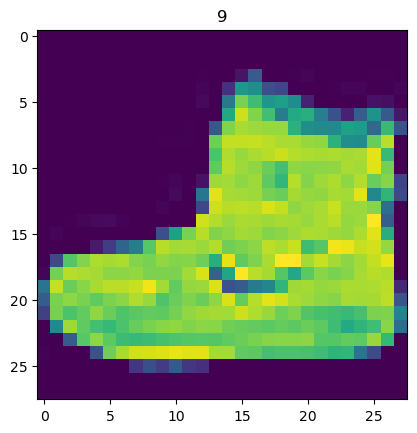

In [54]:
#we squeeze the image so that it is compatible with matplotlib
plt.imshow(image.squeeze())
plt.title(label);

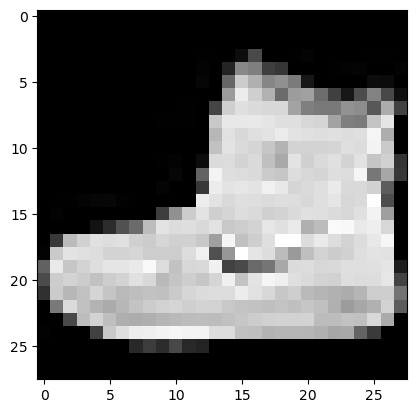

In [55]:
plt.imshow(image.squeeze(),cmap='gray')

37542
46067
46876
46414
10026
27335
38620
11924
14950
57113
31378
29014
47210
18954
18231
47572


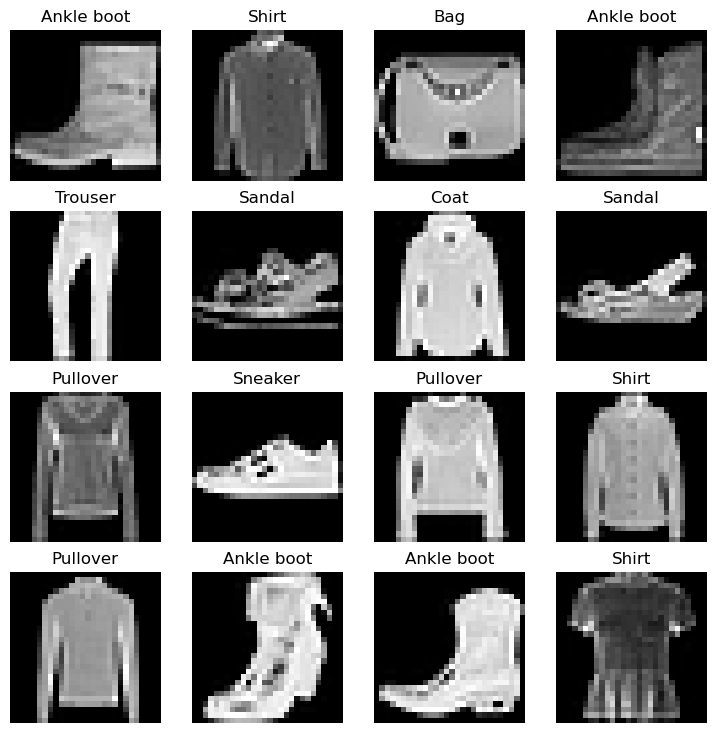

In [56]:
#plot more images
torch.manual_seed(42)
fig = plt.figure(figsize=(9,9))
rows,cols = 4,4
for i in range(1,(rows*cols+1)):
    random_idx = int(torch.randint(0,len(train_data),size=[1]).item())
    print(random_idx)
    img,label = train_data[random_idx]
    fig.add_subplot(rows,cols,i)
    plt.imshow(img.squeeze(),cmap='gray')
    plt.title(class_names[label])
    plt.axis(False)

## 2.Prepare dataloader
Right now, our data is in the form of Pytorch datasets

Dataloader turns our dataset into a python iterable.

More specifically we want to turn our data into batches(or mini-batches)

Why whould we do this:

1.More computationally effecient we cannot put the whole dataset into the ram in one go That's why we split the dataset into batches or mini batches with 32 being the most common batch size

2.It gives our neural network to update its gradients per epoch.


In [57]:
from torch.utils.data import DataLoader
#Setup the batch size hyperparameter
BATCH_SIZE = 32
train_dataloader = DataLoader(batch_size = BATCH_SIZE,dataset = train_data,shuffle = True)
test_dataloader = DataLoader(batch_size = BATCH_SIZE,dataset = test_data,shuffle = False)
train_dataloader , test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x21a46e4a7a0>,
 <torch.utils.data.dataloader.DataLoader at 0x21a46e4b940>)

In [58]:
print(f"Dataloaders : {test_dataloader , train_dataloader}")
print(f"Length of the train dataloder : {len(train_dataloader)}\nBatches of {BATCH_SIZE}\nLength of the test dataloader : {len(test_dataloader)}\nBatches of {BATCH_SIZE}")

Dataloaders : (<torch.utils.data.dataloader.DataLoader object at 0x0000021A46E4B940>, <torch.utils.data.dataloader.DataLoader object at 0x0000021A46E4A7A0>)
Length of the train dataloder : 1875
Batches of 32
Length of the test dataloader : 313
Batches of 32


In [59]:
train_features_batch ,train_labels_batch  = next(iter(train_dataloader))
train_features_batch.shape,train_labels_batch.shape

(torch.Size([32, 1, 28, 28]), torch.Size([32]))

Image size : torch.Size([1, 28, 28])
Label : 6
Labels shape : torch.Size([])


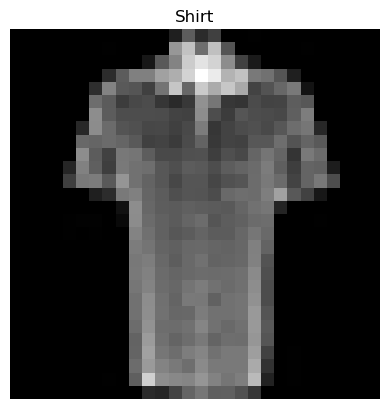

In [60]:
torch.manual_seed(42)
random_idx = torch.randint(0, len(train_features_batch), size=(1,)).item()
img,label = train_features_batch[random_idx],train_labels_batch[random_idx]
plt.imshow(img.squeeze(),cmap='gray')
plt.title(class_names[label])
plt.axis(False)
print(f"Image size : {img.shape}")
print(f"Label : {label}\nLabels shape : {label.shape}")

## 3.Model 0 : Build a baseline model
When starting to build a series of machine learning modelling expierments , it's best practice to start with a baseline model

A baseline model is a simple model you will try and improve upon with subsequent models / expierments

In other words: Start simply and add complexity when neccessary

In [61]:
#Create a flatten layer
flatten_model =   nn.Flatten()
#Get a single sample
x = train_features_batch[0]
x.shape
#Flatten the sample
output = flatten_model(x)#Perform forward pass

#Print out what happened
print(f"Shape before flattening :{x.shape} [color channel,height,width]")
print(f"Shape after flattening : {output.shape}[Color channel, height*width]")

Shape before flattening :torch.Size([1, 28, 28]) [color channel,height,width]
Shape after flattening : torch.Size([1, 784])[Color channel, height*width]


In [62]:
output.shape

torch.Size([1, 784])

In [63]:
from torch import nn    
class MNISTmodel_v0(nn.Module):
    def __init__(self,input_shape: int,hidden_units : int,output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features = input_shape,out_features = hidden_units),
            nn.Linear(in_features = hidden_units , out_features = output_shape))
          
    def forward(self,x):
        return self.layer_stack(x)


In [64]:
torch.manual_seed(42)
#Setup model with input parameters
model_0 = MNISTmodel_v0(input_shape=28*28
,hidden_units= 10 
, output_shape= len(class_names)
).to("cpu")

model_0

MNISTmodel_v0(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): Linear(in_features=10, out_features=10, bias=True)
  )
)

In [65]:
dummy_x = torch.rand([1,1,28,28])
model_0(dummy_x)

tensor([[-0.0315,  0.3171,  0.0531, -0.2525,  0.5959,  0.2112,  0.3233,  0.2694,
         -0.1004,  0.0157]], grad_fn=<AddmmBackward0>)

In [66]:
model_0.state_dict()

OrderedDict([('layer_stack.1.weight',
              tensor([[ 0.0273,  0.0296, -0.0084,  ..., -0.0142,  0.0093,  0.0135],
                      [-0.0188, -0.0354,  0.0187,  ..., -0.0106, -0.0001,  0.0115],
                      [-0.0008,  0.0017,  0.0045,  ..., -0.0127, -0.0188,  0.0059],
                      ...,
                      [-0.0116,  0.0273, -0.0344,  ...,  0.0176,  0.0283, -0.0011],
                      [-0.0230,  0.0257,  0.0291,  ..., -0.0187, -0.0087,  0.0001],
                      [ 0.0176, -0.0147,  0.0053,  ..., -0.0336, -0.0221,  0.0205]])),
             ('layer_stack.1.bias',
              tensor([-0.0093,  0.0283, -0.0033,  0.0255,  0.0017,  0.0037, -0.0302, -0.0123,
                       0.0018,  0.0163])),
             ('layer_stack.2.weight',
              tensor([[ 0.0614, -0.0687,  0.0021,  0.2718,  0.2109,  0.1079, -0.2279, -0.1063,
                        0.2019,  0.2847],
                      [-0.1495,  0.1344, -0.0740,  0.2006, -0.0475, -0.2514, -0.

## 3.1 Setting up loss function , optimizer and evalvuation metircs

* Since it is a mulitclass data loss function is cross entropy nn.CrossEntropyLoss()

* Optimizer = torch.optim.SGD()  stochastic graident descent

* Evalvuation metirc - Since we are working with multi-class classification we weill use accuracy

In [67]:
from helper_function import accuracy_fn
#Setup loss and cross entropy
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(),lr = 0.1)



    

### 3.2 Creating a fucntion to time the expierments

Machine learining is very expiermental 

#### Things to track 

1.Model's performance(Loss and accuracy values)

2.How fast it runs 

In [68]:
from timeit import default_timer as timer

from typing import Union
def print_time(start:float,end:float,device : Union[str, torch.device, None] = None):
    """Prints how long the model took to run or train"""
    total_time = end - start
    print(f"Time on {device} : {total_time:.3f} Seconds")


In [69]:
#Example code
start_time = timer()
#Some code
end_time = timer()
print(print_time(start_time,end_time,device='cpu'))

Time on cpu : 0.000 Seconds
None


### 3.2 Creating a training loop 
1. Loop through ever epoch
2. Loop through training batches,perform training steps,calculate the train loss per batch
3. Loop through testing batches , perform testing steps , calculate the test loss per batch
4. print out what's happening 
5. caclulate time

**The optimizer will update a model's parameters once per batch rather than once per epoch**

In [70]:
#Import tqdm for progress bar
from tqdm.auto import tqdm
torch.manual_seed(42)
start = timer()

epochs = 3 
#Creatinf a traing and testing loop
for epoch in tqdm(range(epochs)):
    print(f"Epoch : {epoch}\n------")
    train_loss = 0
    #Add a loop to loop through the training batches
    for batch, (X,y) in enumerate(train_dataloader): #Trains the model iteratively on single batches
        model_0.train() 
        #1.Forward pass
        y_pred = model_0(X)
        #2.Calcualte the loss (per batch)
        loss = loss_fn(y_pred,y)
        train_loss += loss
        #3. Optimizer zero grad
        optimizer.zero_grad()
        #4.Loss backward
        loss.backward()
        #5.Optimizer step
        optimizer.step()

        #Print out what's happening
        if batch % 400 == 0:
            print(f"Batch : {batch * len(X)}/{len(train_dataloader.dataset)} ")
    #Divide total train loss by length of train dataloader
    train_loss /= len(train_dataloader)
    #testing
    test_loss, test_acc = 0,0
    model_0.eval()
    with torch.inference_mode():
        for X_test,y_test in test_dataloader:
            #1. Forward pass
            test_pred = model_0(X_test)
            #2.Calcualte the loss (Accumilative)
            test_loss += loss_fn(test_pred,y_test)
            #3. Caclualte accuracy
            test_acc += accuracy_fn(y_true= y_test,y_pred = test_pred.argmax(dim = 1))  
        #Calculate test loss average per batch
        test_loss /= len(test_dataloader)
        #Calculate the test acc average per batch
        test_acc /= len(test_dataloader)
    #Print out what's happening
    print(f"\n Train loss: {train_loss:.4f} | Test loss : {test_loss:.4f} , Test accuracy :{test_acc}")
    #Calculate the training time
    end = timer()
    time_model0 = print_time(start,end,device= str(next(model_0.parameters()).device))


     

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch : 0
------
Batch : 0/60000 
Batch : 12800/60000 
Batch : 25600/60000 
Batch : 38400/60000 
Batch : 51200/60000 

 Train loss: 0.5904 | Test loss : 0.5095 , Test accuracy :82.03873801916933
Time on cpu : 5.609 Seconds
Epoch : 1
------
Batch : 0/60000 
Batch : 12800/60000 
Batch : 25600/60000 
Batch : 38400/60000 
Batch : 51200/60000 

 Train loss: 0.4763 | Test loss : 0.4799 , Test accuracy :83.19688498402556
Time on cpu : 11.122 Seconds
Epoch : 2
------
Batch : 0/60000 
Batch : 12800/60000 
Batch : 25600/60000 
Batch : 38400/60000 
Batch : 51200/60000 

 Train loss: 0.4550 | Test loss : 0.4766 , Test accuracy :83.42651757188499
Time on cpu : 16.600 Seconds


## 4. Evalvuating the model

In [71]:
torch.manual_seed(42)
from typing import Union
def eval_model(model:torch.nn.Module,
               data_loader:torch.utils.data.DataLoader,
               loss_fn : torch.nn.Module,
               accuracy_fn,
               device: Union[str, torch.device] = device):
    """Returns a dictionary contatining the results of model predicting on data_laoder"""
    loss: torch.Tensor = torch.tensor(0.0, device=device)
    acc = 0
    model.eval()
    with torch.inference_mode():
        for X,y in tqdm(data_loader):
            #Device agnostic
            X,y = X.to(device) , y.to(device)
            
            #Make predictions
            y_pred = model(X)
            #Accumulate the loss and acc values per batch
            loss += loss_fn(y_pred,y)
            acc += accuracy_fn(y_true = y,y_pred = y_pred.argmax(dim = 1))
            #argmax will function as the softmax activation fucntion as it will return the highest value from the set of ouput logits
        #Scale the loss and acc to find the average loss / acc per batch
        loss /= len(data_loader)
        acc /= len(data_loader)
        return{"model_name":model.__class__.__name__,#Only works when model is created with a class
               "model_loss":loss.item(),
               "model_acc":acc}


In [72]:
#Calculating model 0  results on test dataset

model_0 = model_0.to(device)
model_results = eval_model(model = model_0,data_loader= train_dataloader,loss_fn=loss_fn,accuracy_fn=accuracy_fn)
model_results

  0%|          | 0/1875 [00:00<?, ?it/s]

{'model_name': 'MNISTmodel_v0',
 'model_loss': 0.4302609860897064,
 'model_acc': 84.94166666666666}

## 5. Setting up device agnositc code 

In [73]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

## 6. building a model with non linearity 

In [74]:
#create a model with linear and non linear layers
class MNISTmodel_v1(nn.Module):
    def __init__(self,input_shape: int,hidden_units : int,output_shape: int):
        super().__init__()
        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features = input_shape,out_features = hidden_units),
            nn.ReLU(),
            nn.Linear(in_features = hidden_units , out_features = output_shape),
            nn.ReLU()
            )
          
    def forward(self,x):
        return self.layer_stack(x)


In [75]:
#Creating an instance of v1 model
model_1 = MNISTmodel_v1(input_shape= 28*28 ,hidden_units= 10,output_shape=len(class_names))
model_1.to(device)

MNISTmodel_v1(
  (layer_stack): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=10, bias=True)
    (2): ReLU()
    (3): Linear(in_features=10, out_features=10, bias=True)
    (4): ReLU()
  )
)

## 6.1 Functionizing training and evalvuation\testing loops

train loop - train_step()

test loop - test_loop()

In [76]:

def train_step(model : torch.nn.Module,train_dataloader : torch.utils.data.DataLoader,
loss_fn : torch.nn.Module,optimizer : torch.optim.Optimizer,accuracy_fn,device : Union[str, torch.device] = device):

    """peroforms a training with model training to learn on data_loader"""
    
 
    
    model.train()
    
    
    train_loss,train_acc = 0,0
    #Add a loop to loop through the training batches
    for batch, (X,y) in enumerate(train_dataloader): #Trains the model iteratively on single batches
        X, y = X.to(device) , y.to(device)
         
        #1.Forward pass
        y_pred = model(X)

        #2.Calcualte the loss and acccuracy (per batch)
        loss = loss_fn(y_pred,y)
        train_loss += loss
        train_acc += accuracy_fn(y_true=y , y_pred= y_pred.argmax(dim=1)) #y_pred.argmax(dim = 1) returns the highest value from each row at dimension 1

        #3. Optimizer zero grad
        optimizer.zero_grad()

        #4.Loss backward
        loss.backward()

        #5.Optimizer step
        optimizer.step()

        #Print out what's happening
        if batch % 400 == 0:
            print(f"Batch : {batch * len(X)}/{len(train_dataloader.dataset)} ")
    #Divide total train loss by length of train dataloader
    train_loss /= len(train_dataloader)
    train_acc /= len(train_dataloader)
    
    
    
    print(f"Train loss:{train_loss:.5f}|Train acc:{train_acc:.2f}%")

In [77]:
from typing import Union
def test_step(model : nn.Module,test_dataloader : torch.utils.data.DataLoader,loss_fn : nn.Module,accuracy_fn,device: Union[str, torch.device] = device):
    """Performs a testing loop on model going over data_laoder """
    test_loss,test_acc = 0,0

    model.eval()
    with torch.inference_mode():
        for X ,y in test_dataloader:
            #Send the data to the target device
            X,y = X.to(device),y.to(device)
            #1.forward pass 
            test_pred = model(X)

            test_loss += loss_fn(test_pred,y)
            test_acc += accuracy_fn(y_true = y,y_pred = test_pred.argmax(dim = 1))
        
        #Adjust metrics and print out
        test_loss /= len(test_dataloader)
        test_acc /= len(test_dataloader)
        print(f"Test loss: {test_loss:.5f} | Test acc: {test_acc:.2f}%\n")


In [78]:
from tqdm.auto import tqdm
torch.manual_seed(42)
from helper_function import print_train_time
from timeit import default_timer as timer 
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_1.parameters(),lr = 0.1)
train_time_gpu_start = timer()

#Set epochs
epochs = 3

#Create optimization and evaluation loop using train step and test step
for epoch in tqdm(range(epochs)):   
    print(f"Epoch : {epoch}\n---------")
    train_step(model = model_1 ,train_dataloader= train_dataloader,
    loss_fn= loss_fn,optimizer = optimizer,accuracy_fn = accuracy_fn,device= device)
    test_step(model = model_1,
    test_dataloader= test_dataloader,loss_fn=loss_fn,accuracy_fn= accuracy_fn)

train_time_gpu_end  = timer()
train_time_model_1 = print_train_time(start= train_time_gpu_start,end = train_time_gpu_end,device = device)

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch : 0
---------
Batch : 0/60000 
Batch : 12800/60000 
Batch : 25600/60000 
Batch : 38400/60000 
Batch : 51200/60000 
Train loss:0.69330|Train acc:75.74%
Test loss: 0.55063 | Test acc: 80.61%

Epoch : 1
---------
Batch : 0/60000 
Batch : 12800/60000 
Batch : 25600/60000 
Batch : 38400/60000 
Batch : 51200/60000 
Train loss:0.49621|Train acc:82.27%
Test loss: 0.49627 | Test acc: 82.40%

Epoch : 2
---------
Batch : 0/60000 
Batch : 12800/60000 
Batch : 25600/60000 
Batch : 38400/60000 
Batch : 51200/60000 
Train loss:0.46770|Train acc:83.27%
Test loss: 0.48576 | Test acc: 82.74%


Train time on cuda: 20.097 seconds


In [79]:
#get model_1 results 
model_1_result = eval_model(model=model_1,data_loader=test_dataloader,loss_fn=loss_fn,
                            accuracy_fn=accuracy_fn)

model_1_result

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'MNISTmodel_v1',
 'model_loss': 0.4857630431652069,
 'model_acc': 82.7376198083067}

### Saving model 0

In [83]:
from pathlib import Path
#Creating models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True,exist_ok=True)
#Create a model and save the path
MODEL_NAME = "pytroch_linear_modelv0.pth"
MODEL_SAVE_NAME = MODEL_NAME
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME   
#Save the model's state_dict
print(f"Saving the modell to :{MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(),f=MODEL_SAVE_PATH)


Saving the modell to :models\pytroch_linear_modelv0.pth


### Saving model 1


In [84]:

from pathlib import Path
#Creating models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True,exist_ok=True)
#Create a model and save the path
MODEL_NAME = "pytorch_vision_modelv1.pth"
MODEL_SAVE_NAME = MODEL_NAME
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME   
#Save the model's state_dict
print(f"Saving the modell to :{MODEL_SAVE_PATH}")
torch.save(obj=model_1.state_dict(),f=MODEL_SAVE_PATH)


Saving the modell to :models\pytorch_vision_modelv1.pth
